In [4]:
# %% ================================================================
# [7회차] 표본과 신뢰의 개념 실습
# 목적: 표본평균의 불안정성 → 표집분포 → 중심극한정리 → 표준오차 → 신뢰구간
# Google Colab Notebook 환경 기준
# ===================================================================

# %% 1. 기본 라이브러리 불러오기
# numpy : 수치 계산
# matplotlib : 시각화
# scipy.stats : 정규분포 관련 함수 (z값 계산 등)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 난수 재현성을 위해 seed 고정
np.random.seed(42)


모집단 평균 (실제 모수): 99.6


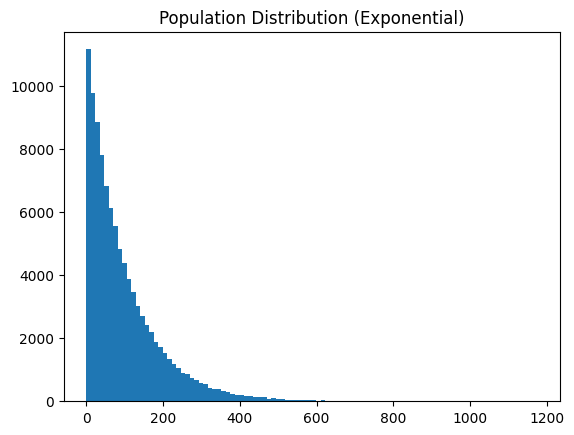

In [5]:
# %% 2. 모집단 생성 (정규분포가 아닌 분포로 설정)
# 이번 실습의 핵심은:
# "모집단이 정규분포가 아니어도 표본평균은 정규에 가까워진다"를 보여주는 것

# 지수분포(exponential distribution)를 모집단으로 사용
# 평균이 100이 되도록 scale=100 설정
population = np.random.exponential(scale=100, size=100000)

# 모집단 평균 (현실에서는 모르는 값)
true_mean = np.mean(population)

print("모집단 평균 (실제 모수):", round(true_mean, 2))

# 모집단 분포 시각화
plt.figure()
plt.hist(population, bins=100)
plt.title("Population Distribution (Exponential)")
plt.show()


표본 평균: 85.8


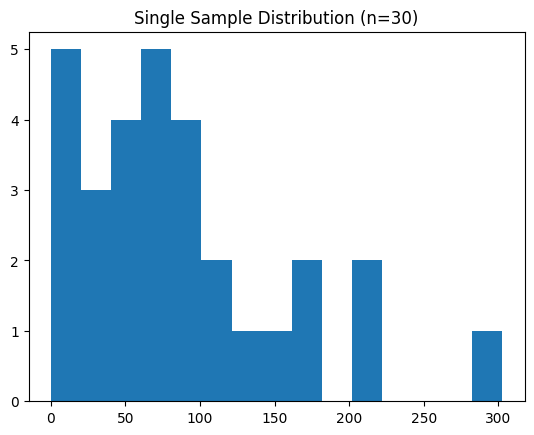

In [6]:
# %% 3. 하나의 표본을 뽑아 평균 계산해보기
# 표본 크기 n 설정
n = 30

sample = np.random.choice(population, size=n, replace=False)
sample_mean = np.mean(sample)

print("표본 평균:", round(sample_mean, 2))

plt.figure()
plt.hist(sample, bins=15)
plt.title("Single Sample Distribution (n=30)")
plt.show()



표본평균들의 평균: 99.64
표본평균들의 표준편차: 18.26


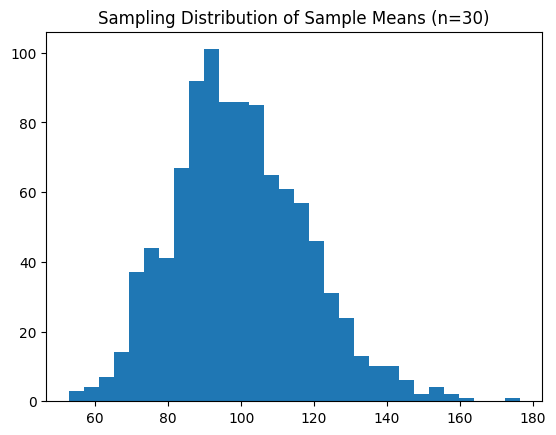

In [7]:
# %% 4. 표본을 여러 번 뽑아보기 (표집분포 만들기)
# 여기서 학생들이 느껴야 할 것:
# "표본평균도 매번 달라진다"

num_samples = 1000
sample_means = []

for _ in range(num_samples):
    s = np.random.choice(population, size=n, replace=False)
    sample_means.append(np.mean(s))

sample_means = np.array(sample_means)

print("표본평균들의 평균:", round(np.mean(sample_means), 2))
print("표본평균들의 표준편차:", round(np.std(sample_means), 2))

plt.figure()
plt.hist(sample_means, bins=30)
plt.title("Sampling Distribution of Sample Means (n=30)")
plt.show()



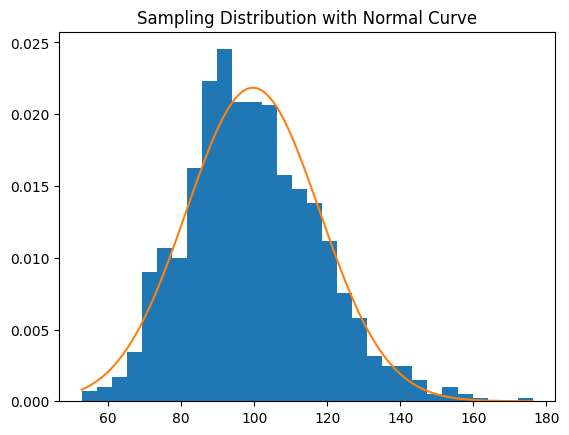

In [8]:

# %% 5. 중심극한정리 확인
# 모집단은 지수분포(비대칭)
# 하지만 표본평균의 분포는 거의 정규분포처럼 보임

# 정규곡선 겹쳐보기
mean_sm = np.mean(sample_means)
std_sm = np.std(sample_means)

x = np.linspace(min(sample_means), max(sample_means), 200)
y = stats.norm.pdf(x, mean_sm, std_sm)

plt.figure()
plt.hist(sample_means, bins=30, density=True)
plt.plot(x, y)
plt.title("Sampling Distribution with Normal Curve")
plt.show()



In [9]:

# %% 6. 표준오차 계산
# 이론적 표준오차 공식: SE = s / sqrt(n)
# 여기서는 모집단 표준편차 대신 sample_means의 실제 표준편차와 비교

sample_std = np.std(population)

theoretical_se = sample_std / np.sqrt(n)
empirical_se = np.std(sample_means)

print("이론적 표준오차:", round(theoretical_se, 2))
print("실험적 표준오차:", round(empirical_se, 2))



이론적 표준오차: 18.13
실험적 표준오차: 18.26


In [10]:

# %% 7. 95% 신뢰구간 계산
# 기본 구조: 평균 ± z * SE
# 95%일 때 z ≈ 1.96

z = 1.96
ci_lower = sample_mean - z * theoretical_se
ci_upper = sample_mean + z * theoretical_se

print("95% 신뢰구간:", (round(ci_lower,2), round(ci_upper,2)))
print("실제 모집단 평균:", round(true_mean,2))


95% 신뢰구간: (np.float64(50.27), np.float64(121.33))
실제 모집단 평균: 99.6


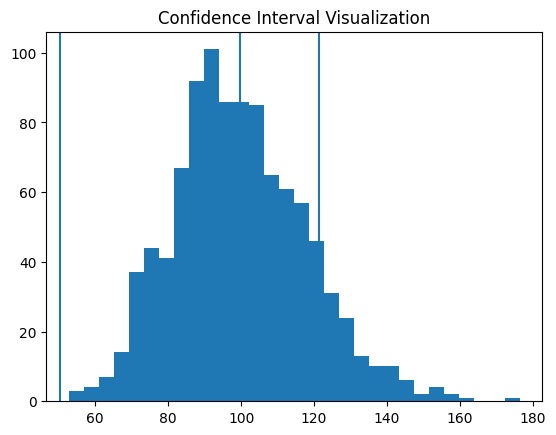

In [11]:
# %% 8. 신뢰구간 시각화
plt.figure()
plt.hist(sample_means, bins=30)
plt.axvline(true_mean)
plt.axvline(ci_lower)
plt.axvline(ci_upper)
plt.title("Confidence Interval Visualization")
plt.show()


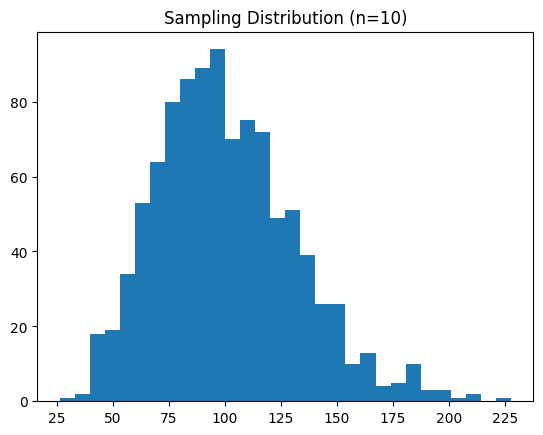

n=10일 때 표본평균의 표준편차(=표준오차): 31.16


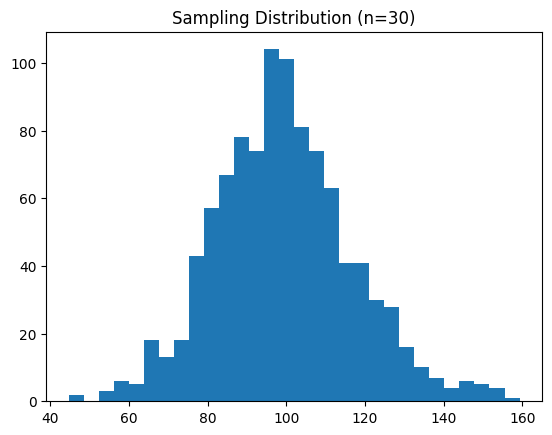

n=30일 때 표본평균의 표준편차(=표준오차): 17.53


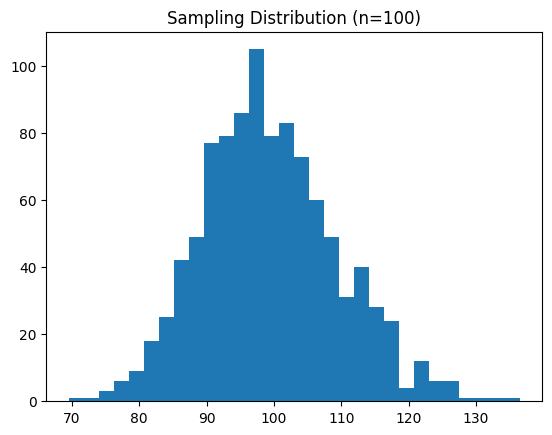

n=100일 때 표본평균의 표준편차(=표준오차): 10.04


In [17]:
# %% 9. 표본 크기 변화에 따른 표준오차 비교
# 핵심 메시지:
# "표본 수가 커질수록 평균의 흔들림(표준오차)은 줄어든다"

sample_sizes = [10, 30, 100]
results = {}

for n in sample_sizes:
    sample_means_n = []
    for _ in range(1000):
        s = np.random.choice(population, size=n, replace=False)
        sample_means_n.append(np.mean(s))
    sample_means_n = np.array(sample_means_n)
    
    results[n] = {
        "means": sample_means_n,
        "se": np.std(sample_means_n)
    }


# 시각화 (각 n에 대해 따로 그림 생성 — 한 그래프에 겹치지 않음)
for n in sample_sizes:
    plt.figure()
    plt.hist(results[n]["means"], bins=30)
    plt.title(f"Sampling Distribution (n={n})")
    plt.show()
    
    print(f"n={n}일 때 표본평균의 표준편차(=표준오차):",
          round(results[n]["se"], 2))



In [14]:

# %% 10. 신뢰수준에 따른 구간 폭 비교
# 신뢰수준이 높을수록 구간은 넓어진다

n = 30
sample = np.random.choice(population, size=n, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

se = sample_std / np.sqrt(n)

confidence_levels = [0.90, 0.95, 0.99]

for cl in confidence_levels:
    z = stats.norm.ppf(1 - (1 - cl) / 2)
    lower = sample_mean - z * se
    upper = sample_mean + z * se
    
    print(f"{int(cl*100)}% 신뢰구간:",
          (round(lower,2), round(upper,2)))



90% 신뢰구간: (np.float64(88.44), np.float64(170.95))
95% 신뢰구간: (np.float64(80.53), np.float64(178.86))
99% 신뢰구간: (np.float64(65.09), np.float64(194.3))


In [18]:

# %% 11. "95% 포함"의 진짜 의미 시뮬레이션
# 많은 학생들이 오해하는 부분:
# "이 구간 안에 모수가 95% 확률로 있다"가 아니다.
# 정확한 의미는:
# 같은 과정을 반복하면 그 중 95%의 구간이 모수를 포함한다.

n = 30
num_experiments = 200
count_contain = 0

for _ in range(num_experiments):
    s = np.random.choice(population, size=n, replace=False)
    mean_s = np.mean(s)
    std_s = np.std(s, ddof=1)
    se_s = std_s / np.sqrt(n)
    
    lower = mean_s - 1.96 * se_s
    upper = mean_s + 1.96 * se_s
    
    if lower <= true_mean <= upper:
        count_contain += 1

print("총 실험 횟수:", num_experiments)
print("모평균을 포함한 구간 수:", count_contain)
print("비율:", round(count_contain / num_experiments, 3))



총 실험 횟수: 200
모평균을 포함한 구간 수: 191
비율: 0.955


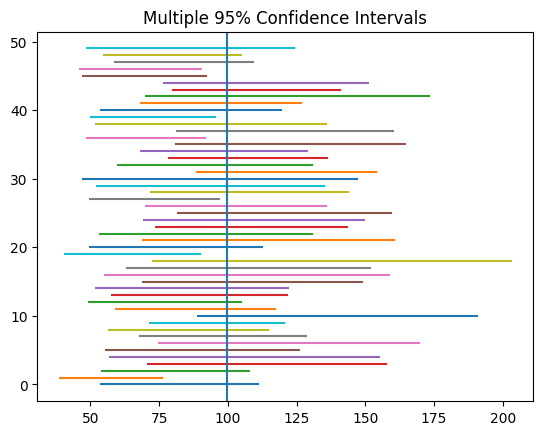

In [19]:

# %% 12. 반복 구간 시각화
# 여러 신뢰구간을 시각적으로 그려
# 실제로 95% 정도가 모수를 포함하는지 확인

plt.figure()

for i in range(50):
    s = np.random.choice(population, size=n, replace=False)
    mean_s = np.mean(s)
    std_s = np.std(s, ddof=1)
    se_s = std_s / np.sqrt(n)
    
    lower = mean_s - 1.96 * se_s
    upper = mean_s + 1.96 * se_s
    
    color = "blue"
    if not (lower <= true_mean <= upper):
        color = "red"
        
    plt.plot([lower, upper], [i, i])

# 실제 모평균 위치 표시
plt.axvline(true_mean)

plt.title("Multiple 95% Confidence Intervals")
plt.show()


In [20]:
import numpy as np

np.random.seed(42)

# 모집단 생성 (비대칭 분포)
population = np.random.exponential(scale=100, size=100000)

true_mean = np.mean(population)
print("모집단 평균:", true_mean)

# 표본 하나 추출
sample = np.random.choice(population, size=30, replace=False)
sample_mean = np.mean(sample)

print("표본 평균:", sample_mean)


모집단 평균: 99.59701590561848
표본 평균: 85.80141818457915


In [21]:
import numpy as np

np.random.seed(42)

# 모집단 생성 (비대칭 분포)
population = np.random.exponential(scale=100, size=100000)

true_mean = np.mean(population)
print("모집단 평균:", true_mean)

# 표본 하나 추출
sample = np.random.choice(population, size=30, replace=False)
sample_mean = np.mean(sample)

print("표본 평균:", sample_mean)


모집단 평균: 99.59701590561848
표본 평균: 85.80141818457915


In [22]:
sample_means = []

for _ in range(1000):
    s = np.random.choice(population, size=30, replace=False)
    sample_means.append(np.mean(s))

sample_means = np.array(sample_means)

print("표본평균들의 평균:", np.mean(sample_means))
print("표본평균들의 표준편차:", np.std(sample_means))


표본평균들의 평균: 99.6420093831514
표본평균들의 표준편차: 18.263979010808924


In [23]:
n = 30
num_experiments = 200
count_contain = 0

for _ in range(num_experiments):
    s = np.random.choice(population, size=n, replace=False)
    mean_s = np.mean(s)
    std_s = np.std(s, ddof=1)
    se_s = std_s / np.sqrt(n)
    
    lower = mean_s - 1.96 * se_s
    upper = mean_s + 1.96 * se_s
    
    if lower <= true_mean <= upper:
        count_contain += 1

print("포함 비율:", count_contain / num_experiments)


포함 비율: 0.92


In [24]:
sample = np.random.choice(population, size=30, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
se = sample_std / np.sqrt(30)

for cl in [0.90, 0.95, 0.99]:
    z = stats.norm.ppf(1 - (1 - cl) / 2)
    lower = sample_mean - z * se
    upper = sample_mean + z * se
    print(f"{int(cl*100)}% 신뢰구간:", (lower, upper))


90% 신뢰구간: (np.float64(54.36109294505243), np.float64(96.08232586984721))
95% 신뢰구간: (np.float64(50.36475174770999), np.float64(100.07866706718966))
99% 신뢰구간: (np.float64(42.554129573294105), np.float64(107.88928924160554))


In [25]:
for n in [10, 30, 100]:
    sample_means = []
    for _ in range(1000):
        s = np.random.choice(population, size=n, replace=False)
        sample_means.append(np.mean(s))
    print(f"n={n}일 때 평균들의 표준편차:", np.std(sample_means))


n=10일 때 평균들의 표준편차: 31.758343812872916
n=30일 때 평균들의 표준편차: 18.30159516470253
n=100일 때 평균들의 표준편차: 9.848040047741504


모집단 평균 (모수 μ): 99.6
모집단 표준편차 (모수 σ): 99.3


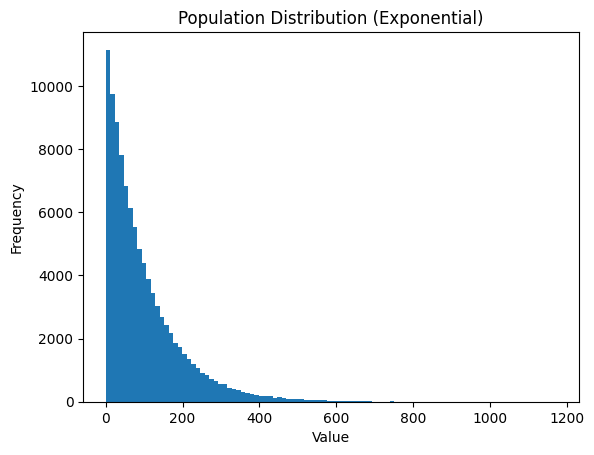

표본 평균 (x̄): 85.8
표본 표준편차 (s): 71.0
표본평균들의 평균: 99.64
표본평균들의 표준편차: 18.26


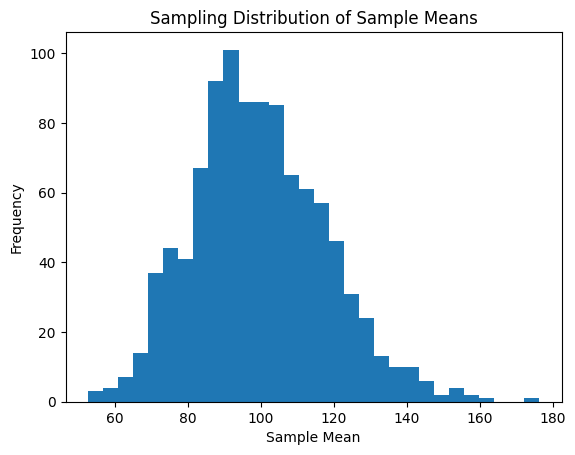

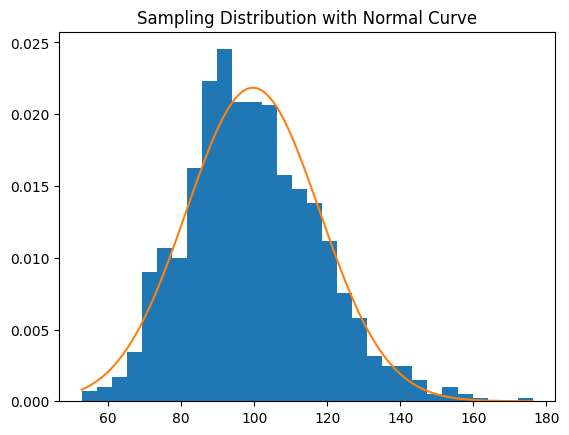

이론적 표준오차 (s/√n): 12.96
실험적 표준오차 (표본평균들의 표준편차): 18.26
95% 신뢰구간: (np.float64(60.39), np.float64(111.21))
실제 모집단 평균: 99.6


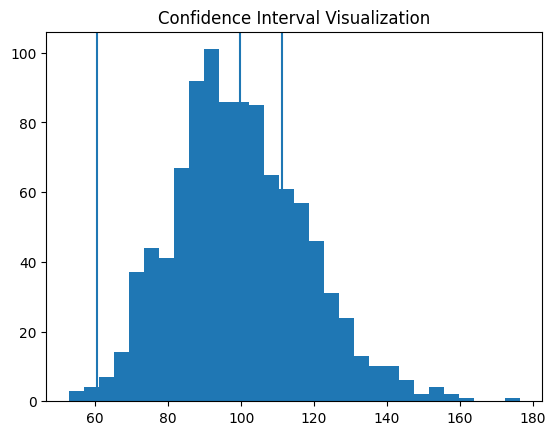

총 실험 횟수: 200
모평균 포함 비율: 0.92


In [26]:
# %% ============================================================
# [7회차 실습] 표본과 신뢰의 개념 전체 실습 코드
# 목적:
# 1) 표본평균도 랜덤임을 확인
# 2) 표집분포 형성 관찰
# 3) 중심극한정리 체감
# 4) 표준오차 이해
# 5) 신뢰구간 계산
# 6) 95% 의미를 반복 실험으로 확인
# ============================================================

# %% 1. 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 난수 고정 (재현성 확보)
np.random.seed(42)


# %% 2. 모집단 생성
# 모집단은 일부러 정규분포가 아닌 "지수분포"로 설정
# 이유: 중심극한정리가 "모집단이 정규가 아니어도" 성립함을 보여주기 위함

population = np.random.exponential(scale=100, size=100000)

true_mean = np.mean(population)
true_std = np.std(population)

print("모집단 평균 (모수 μ):", round(true_mean, 2))
print("모집단 표준편차 (모수 σ):", round(true_std, 2))

# 모집단 분포 시각화
plt.figure()
plt.hist(population, bins=100)
plt.title("Population Distribution (Exponential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


# %% 3. 표본 하나 추출
# 표본 크기 n 설정
n = 30

sample = np.random.choice(population, size=n, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

print("표본 평균 (x̄):", round(sample_mean, 2))
print("표본 표준편차 (s):", round(sample_std, 2))

# 여기서 질문:
# 표본 평균은 모집단 평균과 정확히 같은가?
# -> 아니다. 표본평균도 랜덤이다.


# %% 4. 표본을 여러 번 뽑아 평균들의 분포 만들기 (표집분포)
# 이 단계가 중심극한정리의 핵심 체험 구간

num_samples = 1000
sample_means = []

for _ in range(num_samples):
    s = np.random.choice(population, size=n, replace=False)
    sample_means.append(np.mean(s))

sample_means = np.array(sample_means)

print("표본평균들의 평균:", round(np.mean(sample_means), 2))
print("표본평균들의 표준편차:", round(np.std(sample_means), 2))

# 표집분포 시각화
plt.figure()
plt.hist(sample_means, bins=30)
plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

# 질문:
# 모집단은 비대칭이었는데, 왜 평균들의 분포는 종 모양일까?


# %% 5. 중심극한정리 확인 (정규곡선 겹치기)
mean_sm = np.mean(sample_means)
std_sm = np.std(sample_means)

x = np.linspace(min(sample_means), max(sample_means), 200)
y = stats.norm.pdf(x, mean_sm, std_sm)

plt.figure()
plt.hist(sample_means, bins=30, density=True)
plt.plot(x, y)
plt.title("Sampling Distribution with Normal Curve")
plt.show()

# 해석:
# 모집단은 정규가 아니었지만,
# 표본평균의 분포는 정규에 가까워짐.


# %% 6. 표준오차 계산
# 이론적 표준오차 공식: SE = s / sqrt(n)

theoretical_se = sample_std / np.sqrt(n)
empirical_se = np.std(sample_means)

print("이론적 표준오차 (s/√n):", round(theoretical_se, 2))
print("실험적 표준오차 (표본평균들의 표준편차):", round(empirical_se, 2))

# 질문:
# 왜 n이 커질수록 표준오차는 작아질까?
# -> 평균은 흔들림이 상쇄되기 때문


# %% 7. 95% 신뢰구간 계산
# 공식: x̄ ± z * SE
# 95%일 때 z ≈ 1.96

z = 1.96

ci_lower = sample_mean - z * theoretical_se
ci_upper = sample_mean + z * theoretical_se

print("95% 신뢰구간:", (round(ci_lower, 2), round(ci_upper, 2)))
print("실제 모집단 평균:", round(true_mean, 2))

# 질문:
# 모집단 평균이 항상 이 구간 안에 있을까?


# %% 8. 신뢰구간 시각화
plt.figure()
plt.hist(sample_means, bins=30)
plt.axvline(true_mean)
plt.axvline(ci_lower)
plt.axvline(ci_upper)
plt.title("Confidence Interval Visualization")
plt.show()

# 여기서 중요한 질문:
# 95%라는 말은 무슨 의미인가?
# "모평균이 95% 확률로 안에 있다"가 아니다.


# %% 9. 95% 의미를 반복 실험으로 확인
num_experiments = 200
count_contain = 0

for _ in range(num_experiments):
    s = np.random.choice(population, size=n, replace=False)
    mean_s = np.mean(s)
    std_s = np.std(s, ddof=1)
    se_s = std_s / np.sqrt(n)
    
    lower = mean_s - 1.96 * se_s
    upper = mean_s + 1.96 * se_s
    
    if lower <= true_mean <= upper:
        count_contain += 1

print("총 실험 횟수:", num_experiments)
print("모평균 포함 비율:", round(count_contain / num_experiments, 3))

# 해석:
# 약 0.95 근처가 나오면 성공.
# 이것이 신뢰구간의 진짜 의미.
